In [1]:
from collections import defaultdict

import torch
import torch.nn.functional as F
import networkx as nx
import numpy as np
import scipy as sp
from scipy.stats import ortho_group
import matplotlib.pyplot as plt

from t_regs.utils.estimate_spectral_norm import est_spectral_norm

from t_regs.manifolds import Steifel, GeneralizedSteifel
from t_regs.solvers.manifold.minimax_problem import MinimaxProblem
from t_regs.solvers.manifold.line_searcher import ArmijoPointSearch
# from t_regs.solvers.manifold.riemannian_ada import RADA_RGD
from t_regs.solvers.manifold.rada import RADA_RGD

from time import perf_counter

### Scenario 1:

$$\mathbf{X}_{n\times p} = \sum_{k=1}^{K} d_k \mathbf{u}_k \mathbf{v}_k^T 
+ \mathbf{E}$$

Where
- $E_{i,j} \sim \mathcal{N}(0,1)$
- $d_1=n/4$, $d_2=n/5$, $d_3=n/6$
- $\mathbf{u}_k \sim O(n, K)$
- $\mathbf{v}_k$ is from sinusoidal pulses
- p=200

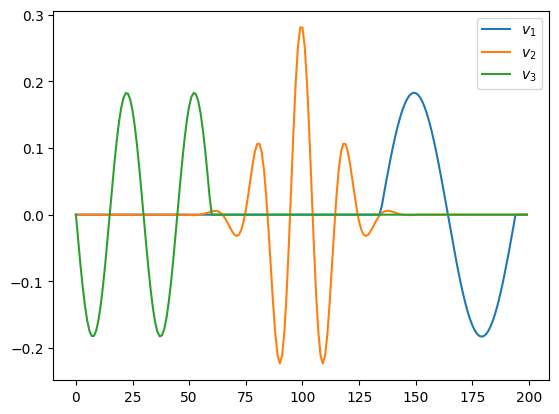

In [2]:
seed = 0
rng = np.random.default_rng(seed)
p = 200
n = 200
K = 3

t = np.linspace(0, 10*np.pi, p)

v = -np.cos(t*2/3)
start = 135
end = 195
v_1 = np.zeros_like(v)
v_1[start:end] = v[start:end]
v_1 = v_1/np.linalg.norm(v_1)

v_2 = np.cos(t*2)
v_2 = np.exp(-0.5*((t - 5*np.pi)/(0.7*np.pi))**2) * v_2
v_2[np.abs(v_2)< 1e-3] = 0
v_2 = v_2/np.linalg.norm(v_2)

v_3 = -1*np.sin(t*4/3)
v_3[60:] = 0
v_3 = v_3/np.linalg.norm(v_3)

plt.plot(v_1, label=r"$v_1$")
plt.plot(v_2, label=r"$v_2$")
plt.plot(v_3, label=r"$v_3$")
plt.legend()
plt.show()

V = np.vstack([v_1, v_2, v_3]).T
U = ortho_group.rvs(dim=n, random_state=seed)[:, :K]

d = np.diag(np.array([n/4, n/5, n/6]))

M = U @ d @ V.T
E = rng.normal(size=(n, p))
X = M + E

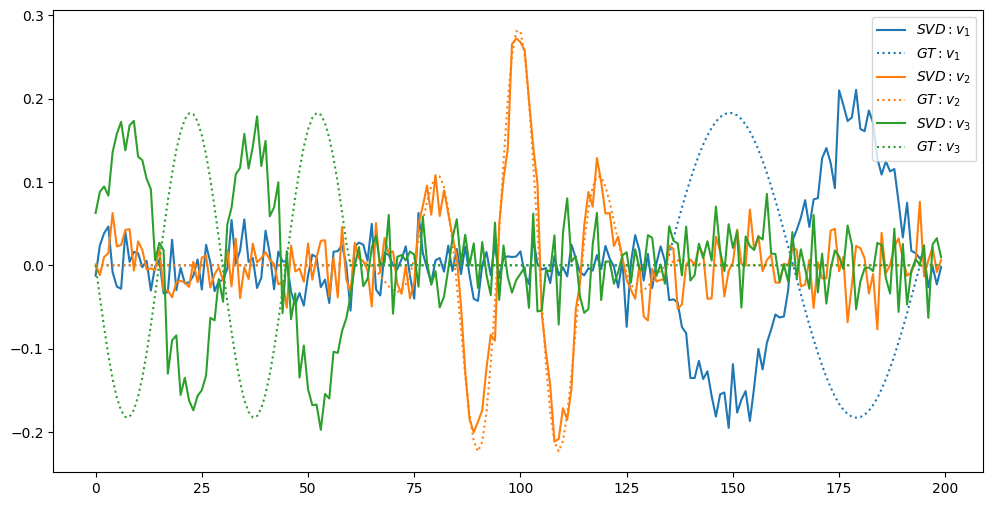

In [3]:
X = torch.tensor(X, dtype=torch.float64, device='cuda')
U_svd, s_svd, V_svd = torch.linalg.svd(X, full_matrices=False)

V_svd = V_svd.T
V_svd = V_svd[:, :K]

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
colors = ['C0', 'C1', 'C2']

for i in range(K):
    v_svd = V_svd[:, i].cpu().numpy()
    # if v_svd.sum() <= 0:
    #     v_svd = -v_svd
    ax.plot(v_svd, label=f"$SVD: v_{i+1}$", color=colors[i])

    v_gt = V[:, i]
    # if v_gt.sum() <= 0:
    #     v_gt = -v_gt
    ax.plot(v_gt, label=f"$GT: v_{i+1}$", color=colors[i], linestyle='dotted')

ax.legend()

## Initialize Minimax Problem
### for Sparse PCA

$$\min_{U\in \mathrm{St}(n, r)} -\langle U U^\top, X X^\top\rangle + \mu \|X\|_1$$

$$\min_{U\in \mathrm{St}(n, r)} \max_{Y\in \mathbb{R}^{n\times r}} -\langle U U^\top, X X^\top\rangle + \langle U,Y \rangle - h(Y)$$

where $h(Y) = \iota_{\mathcal{Y}}(Y)$ where $\iota$ is the indicator function of the set $\mathcal{Y}=\{Y\in \mathbb{R}^{n\times r}| \|Y\|_\infty \leq \mu\}$


In [70]:
mu = 200
manifold = Steifel(p, K, device=X.device)
M = torch.tensor(M, device=X.device, dtype=X.dtype)
def func_f(U):
    utx = U.T@X.T
    # utx = U.T@M.T
    return - utx.pow(2).sum()

def func_h(Y, *vargs, **kwargs):
    linf_y = Y.abs().max()
    if linf_y > mu:
        return torch.inf
    else:
        return 0

def prox_h(Y, *vargs, **kwargs):
    return torch.clamp(Y, -mu, +mu)

mapping_A = torch.eye(p, device=X.device, dtype=X.dtype)
nabla_AT = mapping_A.T

mnmx_problem = MinimaxProblem(
    manifold,
    func_f,
    func_h,
    prox_h,
    mapping_A,
    nabla_AT
    )

/tmp/ipykernel_2141209/3693422047.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  M = torch.tensor(M, device=X.device, dtype=X.dtype)


In [84]:
U_0 = manifold.random_point()
U_0.requires_grad = True
loss = mnmx_problem.func_f(U_0, backward_pass=False)

with torch.no_grad():
    Z = mnmx_problem.A(U_0)
    print("h(Z)=", mnmx_problem.func_h(Z))
    Y_0 = mnmx_problem.prox_h(Z)
    print("h(Y_0)=", mnmx_problem.func_h(Y_0))
    # ones = torch.ones_like(U_0)
    R = mu*U_0.numel()**0.5
    print("R=", R)


solver = RADA_RGD(
    R=R,
    c1=1e-1,
    max_it=10000,
    Tk=10,
    max_line_search=10,
    beta1=10,#0.01*p*K**0.5,
    rho=2.0,
    tau_1=0.999,
    tau_2=0.9,
    zeta=1.0,
    zeta_BB_min=1e-20,
    zeta_BB_max=1e20,
    eps=1e-8,
    max_time= None,
    max_function_evals=10*1000*5,
    verbosity=2,
)
print("lda:", solver.lda)
result = solver.solve(mnmx_problem, x0=U_0, y0=Y_0)

h(Z)= 0
h(Y_0)= 0
R= 4898.979485566356
lda: 1.0206207261596577e-12
RADA RGD Optimizing...
k        t     f(x)                   <A(x), y>          Φ_k(x)                 ||grad Φ_k(x)||    δ_k            β_k            ν_k            ζ_kt (Step Size)    ζ_kt (Armijo)    Step count    
-----    --    -------------------    ---------------    -------------------    ---------------    -----------    -----------    -----------    ----------------    -------------    ----------    
    0     0    -6.675821611172e+02    +3.30000000e+00    -6.644321611172e+02    1.071451e+03       2.34503e-01    1.00000e+01    4.80000e+08    1.00000e+00         
    1    10    -6.088218747982e+03    +1.99386886e+00    -6.086891545786e+03    1.254526e+01       2.07908e-01    2.25000e+00    4.80000e+08    1.83522e-04         4.01363e-04       1            
    2    10    -6.088231821889e+03    +4.99246774e+00    -6.084739354153e+03    2.647918e-02       2.08037e-01    1.00000e+00    4.80000e+08    7.76198e-05  

/tmp/ipykernel_2141209/2742214469.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X, dtype=torch.float64, device='cuda')


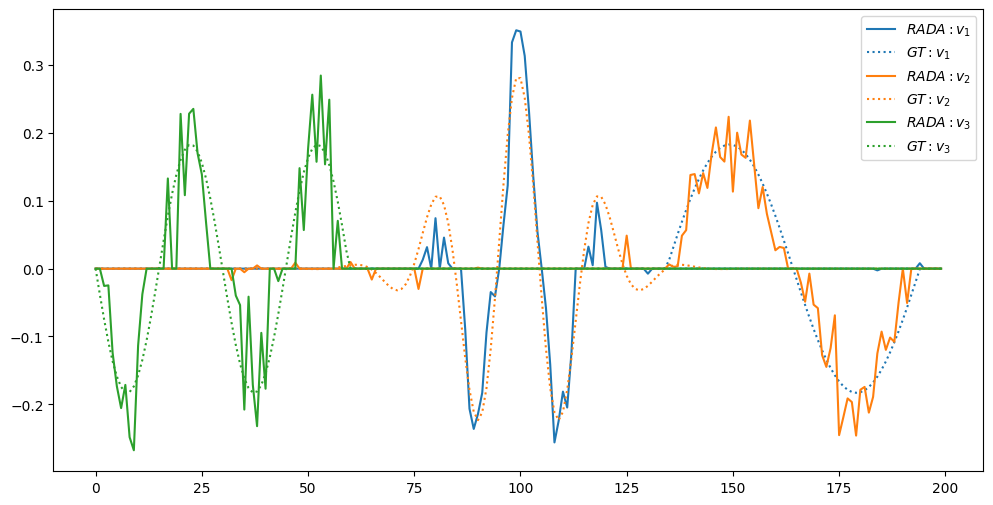

In [85]:
U_tilde = result.point.x
Y_tilde = result.point.y

U_t = U_tilde.cpu().numpy()
Y_t = Y_tilde.cpu().numpy()

X = torch.tensor(X, dtype=torch.float64, device='cuda')
U_svd, s_svd, V_svd = torch.linalg.svd(X, full_matrices=False)

V_svd = V_svd.T
V_svd = V_svd[:, :K]

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
colors = ['C0', 'C1', 'C2']

for i in range(K):
    v_rada = U_t[:, i]
    # if v_svd.sum() <= 0:
    #     v_svd = -v_svd
    ax.plot(v_rada, label=f"$RADA: v_{i+1}$", color=colors[i])

    v_gt = V[:, i]
    # if v_gt.sum() <= 0:
    #     v_gt = -v_gt
    ax.plot(v_gt, label=f"$GT: v_{i+1}$", color=colors[i], linestyle='dotted')

ax.legend()

In [120]:
mu = 100
alpha = 5.0
Gv = nx.path_graph(p)
L2 = nx.laplacian_matrix(Gv)
L2 = torch.tensor(L2.toarray(), dtype=torch.float64, device=X.device)
W2 = torch.eye(p, device=X.device, dtype=X.dtype) +alpha*L2
manifold = GeneralizedSteifel(p,
    K,
    W2,
    device=X.device,
    dtype=X.dtype
    )

def func_f(U):
    utx = U.T@X.T
    # utx = U.T@M.T
    return - utx.pow(2).sum()

def func_h(Y, *vargs, **kwargs):
    linf_y = Y.abs().max()
    if linf_y > mu:
        return torch.inf
    else:
        return 0

def prox_h(Y, *vargs, **kwargs):
    return torch.clamp(Y, -mu, +mu)

mapping_A = torch.eye(p, device=X.device, dtype=X.dtype)
nabla_AT = mapping_A.T

mnmx_problem = MinimaxProblem(
    manifold,
    func_f,
    func_h,
    prox_h,
    mapping_A,
    nabla_AT
    )

In [121]:
U_0 = manifold.random_point()
U_0.requires_grad = True
loss = mnmx_problem.func_f(U_0, backward_pass=False)

with torch.no_grad():
    Z = mnmx_problem.A(U_0)
    print("h(Z)=", mnmx_problem.func_h(Z))
    Y_0 = mnmx_problem.prox_h(Z)
    print("h(Y_0)=", mnmx_problem.func_h(Y_0))
    # ones = torch.ones_like(U_0)
    R = mu*U_0.numel()**0.5
    print("R=", R)


solver = RADA_RGD(
    R=R,
    c1=1e-4,
    max_it=10000,
    Tk=10,
    max_line_search=10,
    beta1=1.0*p*K**0.5,
    rho=3,
    tau_1=0.999,
    tau_2=0.9,
    zeta=1.0,
    zeta_BB_min=1e-20,
    zeta_BB_max=1e20,
    eps=1e-8,
    max_time= None,
    max_function_evals=10*1000*5,
    verbosity=2,
)
print("lda:", solver.lda)
result = solver.solve(mnmx_problem, x0=U_0, y0=Y_0)

h(Z)= 0
h(Y_0)= 0
R= 2449.489742783178
lda: 2.0412414523193154e-12
RADA RGD Optimizing...
k        t     f(x)                   <A(x), y>          Φ_k(x)                 ||grad Φ_k(x)||    δ_k            β_k            ν_k            ζ_kt (Step Size)    ζ_kt (Armijo)    Step count    
-----    --    -------------------    ---------------    -------------------    ---------------    -----------    -----------    -----------    ----------------    -------------    ----------    
    0     0    -6.112634074925e+01    +2.78992401e-01    -6.084774987968e+01    2.978217e+02       6.73561e-02    3.46410e+02    4.15692e+09    1.00000e+00         
    1    10    -2.453093822990e+03    +6.94906572e-02    -2.453039046616e+03    6.810358e+01       1.50342e-01    3.89711e+01    4.15692e+09    2.00185e-04         2.20054e-04       1            
    2    10    -2.455260411638e+03    +1.24216661e-01    -2.455185909396e+03    6.773611e+01       1.47156e-01    1.15470e+01    4.15692e+09    9.90569e-05  

/tmp/ipykernel_2141209/2742214469.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X, dtype=torch.float64, device='cuda')


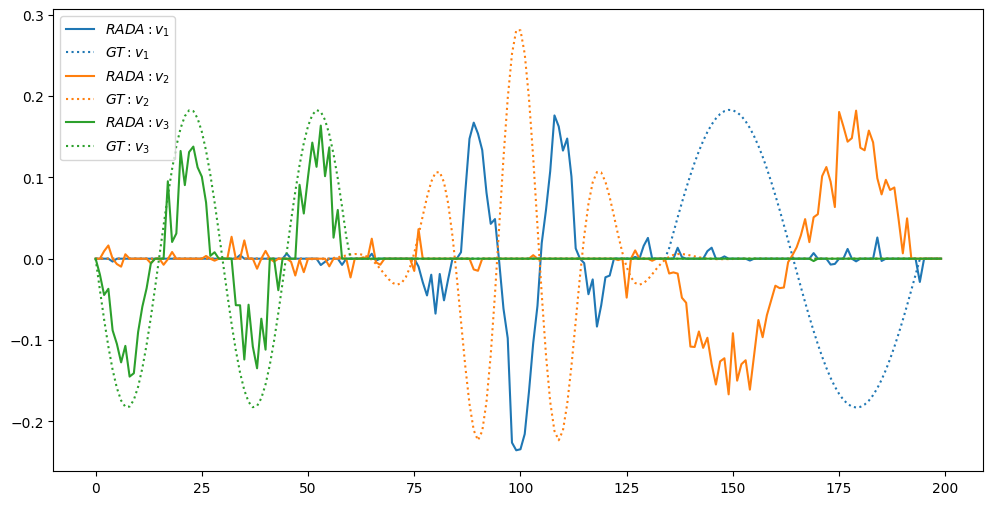

In [122]:
U_tilde = result.point.x
Y_tilde = result.point.y

U_t = U_tilde.cpu().numpy()
Y_t = Y_tilde.cpu().numpy()

X = torch.tensor(X, dtype=torch.float64, device='cuda')
U_svd, s_svd, V_svd = torch.linalg.svd(X, full_matrices=False)

V_svd = V_svd.T
V_svd = V_svd[:, :K]

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
colors = ['C0', 'C1', 'C2']

for i in range(K):
    v_rada = U_t[:, i]
    # if v_svd.sum() <= 0:
    #     v_svd = -v_svd
    ax.plot(v_rada, label=f"$RADA: v_{i+1}$", color=colors[i])

    v_gt = V[:, i]
    # if v_gt.sum() <= 0:
    #     v_gt = -v_gt
    ax.plot(v_gt, label=f"$GT: v_{i+1}$", color=colors[i], linestyle='dotted')

ax.legend()

In [153]:
mu = 10
alpha = 1.0
Gv = nx.path_graph(p)
L2 = nx.laplacian_matrix(Gv)
L2 = torch.tensor(L2.toarray(), dtype=torch.float64, device=X.device)
W2 = torch.eye(p, device=X.device, dtype=X.dtype) +alpha*L2
# manifold = GeneralizedSteifel(p,
#     K,
#     W2,
#     device=X.device,
#     dtype=X.dtype
#     )
manifold = Steifel(p, K, device=X.device)

def func_f(U):
    utx = U.T@X.T
    # utx = U.T@M.T
    return - utx.pow(2).sum()

def func_h(Y, *vargs, **kwargs):
    linf_y = Y.abs().max()
    if linf_y > mu:
        return torch.inf
    else:
        return 0

def prox_h(Y, *vargs, **kwargs):
    return torch.clamp(Y, -mu, +mu)

mapping_A = L2#torch.eye(p, device=X.device, dtype=X.dtype)
nabla_AT = mapping_A.T

mnmx_problem = MinimaxProblem(
    manifold,
    func_f,
    func_h,
    prox_h,
    mapping_A,
    nabla_AT
    )

In [154]:
U_0 = manifold.random_point()
U_0.requires_grad = True
loss = mnmx_problem.func_f(U_0, backward_pass=False)

with torch.no_grad():
    Z = mnmx_problem.A(U_0)
    print("h(Z)=", mnmx_problem.func_h(Z))
    Y_0 = mnmx_problem.prox_h(Z)
    print("h(Y_0)=", mnmx_problem.func_h(Y_0))
    # ones = torch.ones_like(U_0)
    R = mu*(U_0.numel()/4)**0.5
    print("R=", R)


solver = RADA_RGD(
    R=R,
    c1=1e-4,
    max_it=1000,
    Tk=5,
    max_line_search=10,
    beta1=0.1*p*K**0.5,
    rho=2,
    tau_1=0.999,
    tau_2=0.9,
    zeta=1.0,
    zeta_BB_min=1e-20,
    zeta_BB_max=1e20,
    eps=1e-10,
    max_time= None,
    max_function_evals=10*1000*5,
    verbosity=2,
)
print("lda:", solver.lda)
result = solver.solve(mnmx_problem, x0=U_0, y0=Y_0)

h(Z)= 0
h(Y_0)= 0
R= 122.4744871391589
lda: 4.082482904638631e-13
RADA RGD Optimizing...
k      t    f(x)                   <A(x), y>          Φ_k(x)                 ||grad Φ_k(x)||    δ_k            β_k            ν_k            ζ_kt (Step Size)    ζ_kt (Armijo)    Step count    
---    -    -------------------    ---------------    -------------------    ---------------    -----------    -----------    -----------    ----------------    -------------    ----------    
  0    0    -6.341284031386e+02    +1.96603391e+01    -6.147438746097e+02    8.066441e+02       5.92076e-01    3.46410e+01    1.03923e+06    1.00000e+00         
  1    5    -6.058911303704e+03    +7.08761672e-01    -6.058404788603e+03    2.979101e+02       2.29813e-01    7.79423e+00    1.03923e+06    2.34828e-04         2.11710e-04       1            
  2    5    -6.088193336638e+03    +1.12550877e+00    -6.087470670821e+03    5.247504e+00       2.21253e-01    3.46410e+00    1.03923e+06    1.85513e-04         1.83706e-

/tmp/ipykernel_2141209/2742214469.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X, dtype=torch.float64, device='cuda')


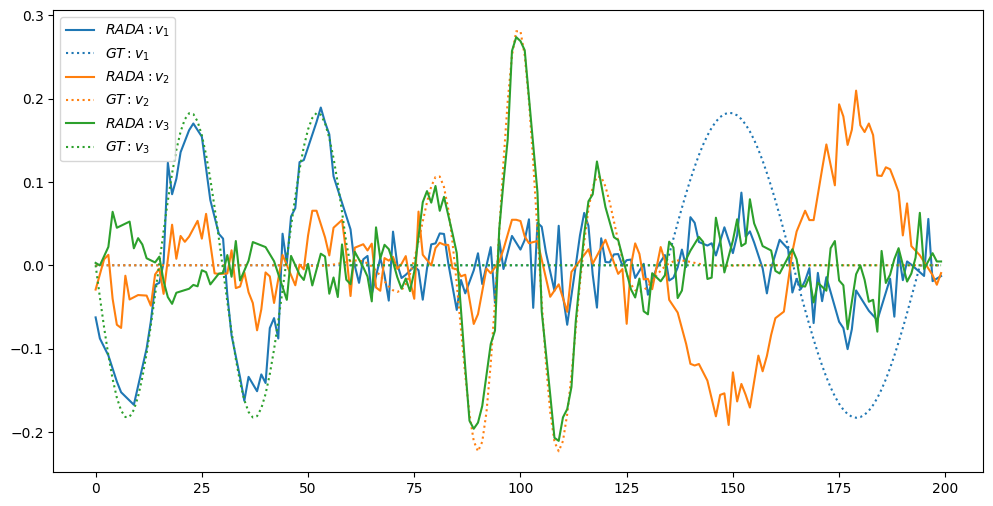

In [156]:
U_tilde = result.point.x
Y_tilde = result.point.y

U_t = U_tilde.cpu().numpy()
Y_t = Y_tilde.cpu().numpy()

X = torch.tensor(X, dtype=torch.float64, device='cuda')
U_svd, s_svd, V_svd = torch.linalg.svd(X, full_matrices=False)

V_svd = V_svd.T
V_svd = V_svd[:, :K]

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
colors = ['C0', 'C1', 'C2']

for i in range(K):
    v_rada = U_t[:, i]
    # if v_svd.sum() <= 0:
    #     v_svd = -v_svd
    ax.plot(v_rada, label=f"$RADA: v_{i+1}$", color=colors[i])

    v_gt = V[:, i]
    # if v_gt.sum() <= 0:
    #     v_gt = -v_gt
    ax.plot(v_gt, label=f"$GT: v_{i+1}$", color=colors[i], linestyle='dotted')

ax.legend()

In [4]:
mu = 100
alpha = 0.1
alpha2 = 0.5
Gv = nx.path_graph(p)
I = torch.eye(p, device=X.device, dtype=X.dtype)
B = nx.incidence_matrix(Gv, oriented=True).todense()
B = torch.tensor(B, dtype=torch.float64, device=X.device)
L2 = nx.laplacian_matrix(Gv)
L2 = torch.tensor(L2.toarray(), dtype=torch.float64, device=X.device)
W2 = torch.eye(p, device=X.device, dtype=X.dtype) +alpha*L2
# D = torch.concat((I, B.T*alpha2))
D = torch.concat((I, L2*alpha2))

In [8]:
mu = 100
alpha = 0.5
Gv = nx.path_graph(p)
I = torch.eye(p, device=X.device, dtype=X.dtype)
B = nx.incidence_matrix(Gv, oriented=True).toarray()
B = torch.tensor(B, dtype=torch.float64, device=X.device)
L2 = nx.laplacian_matrix(Gv)
L2 = torch.tensor(L2.toarray(), dtype=torch.float64, device=X.device)
W2 = torch.eye(p, device=X.device, dtype=X.dtype) +alpha*L2
manifold = GeneralizedSteifel(p,
    K,
    W2,
    device=X.device,
    dtype=X.dtype
    )
# manifold = Steifel(p, K, device=X.device)

def func_f(U):
    utx = U.T@X.T
    # utx = U.T@M.T
    return - utx.pow(2).sum()

def func_h(Y, *vargs, **kwargs):
    linf_y = Y.abs().max()
    if linf_y > mu:
        return torch.inf
    else:
        return 0

def prox_h(Y, *vargs, **kwargs):
    return torch.clamp(Y, -mu, +mu)

mapping_A = D#torch.eye(p, device=X.device, dtype=X.dtype)
nabla_AT = mapping_A.T

mnmx_problem = MinimaxProblem(
    manifold,
    func_f,
    func_h,
    prox_h,
    mapping_A,
    nabla_AT
    )

In [9]:
U_0 = manifold.random_point()
U_0.requires_grad = True
loss = mnmx_problem.func_f(U_0, backward_pass=False)

with torch.no_grad():
    Z = mnmx_problem.A(U_0)
    print("h(Z)=", mnmx_problem.func_h(Z))
    Y_0 = mnmx_problem.prox_h(Z)
    print("h(Y_0)=", mnmx_problem.func_h(Y_0))
    # ones = torch.ones_like(U_0)
    R = mu*(U_0.numel()/4)**0.5
    print("R=", R)


solver = RADA_RGD(
    R=R,
    c1=1e-4,
    max_it=1000,
    Tk=10,
    max_line_search=10,
    beta1=0.1*p*K**0.5,
    rho=2,
    tau_1=0.999,
    tau_2=0.9,
    zeta=1.0,
    zeta_BB_min=1e-20,
    zeta_BB_max=1e20,
    eps=1e-10,
    max_time= None,
    max_function_evals=10*1000*5,
    verbosity=2,
)
print("lda:", solver.lda)
result = solver.solve(mnmx_problem, x0=U_0, y0=Y_0)

h(Z)= 0
h(Y_0)= 0
R= 1224.744871391589
lda: 4.0824829046386307e-14
RADA RGD Optimizing...
k      t     f(x)                   <A(x), y>          Φ_k(x)                 ||grad Φ_k(x)||    δ_k            β_k            ν_k            ζ_kt (Step Size)    ζ_kt (Armijo)    Step count    
---    --    -------------------    ---------------    -------------------    ---------------    -----------    -----------    -----------    ----------------    -------------    ----------    
  0     0    -3.340144299026e+02    +3.84588445e+00    -3.302224985263e+02    6.523279e+02       2.44450e-01    3.46410e+01    1.03923e+08    1.00000e+00         
  1    10    -5.265329632490e+03    +7.10223169e-01    -5.264821448751e+03    2.408143e+01       1.83504e-01    7.79423e+00    1.03923e+08    1.86883e-04         2.04470e-04       1            
  2    10    -5.230125186625e+03    +1.59403149e+00    -5.228987224101e+03    2.713116e+02       2.11702e-01    3.46410e+00    1.03923e+08    2.54072e-04         1.0

/tmp/ipykernel_2216867/2742214469.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X, dtype=torch.float64, device='cuda')


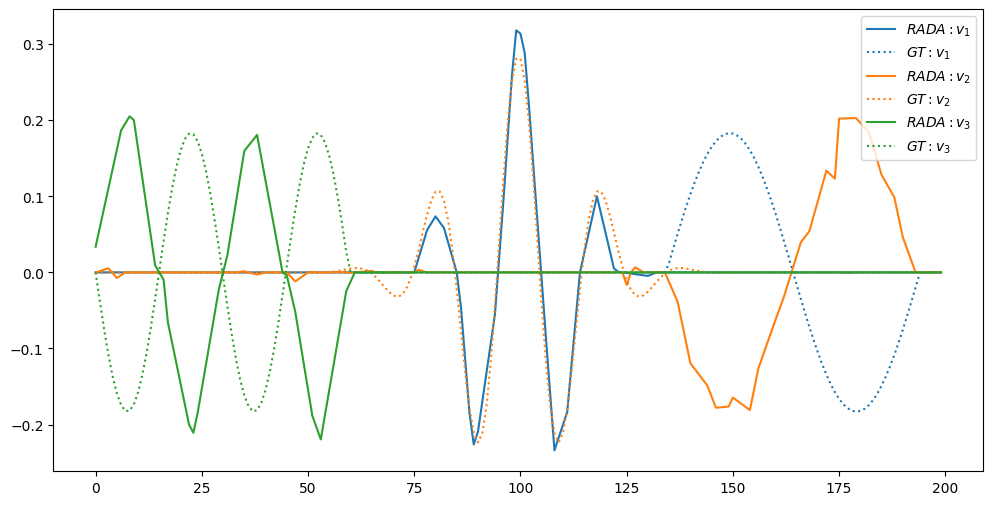

In [10]:
U_tilde = result.point.x
Y_tilde = result.point.y

U_t = U_tilde.cpu().numpy()
Y_t = Y_tilde.cpu().numpy()

X = torch.tensor(X, dtype=torch.float64, device='cuda')
U_svd, s_svd, V_svd = torch.linalg.svd(X, full_matrices=False)

V_svd = V_svd.T
V_svd = V_svd[:, :K]

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
colors = ['C0', 'C1', 'C2']

for i in range(K):
    v_rada = U_t[:, i]
    # if v_svd.sum() <= 0:
    #     v_svd = -v_svd
    ax.plot(v_rada, label=f"$RADA: v_{i+1}$", color=colors[i])

    v_gt = V[:, i]
    # if v_gt.sum() <= 0:
    #     v_gt = -v_gt
    ax.plot(v_gt, label=f"$GT: v_{i+1}$", color=colors[i], linestyle='dotted')

ax.legend()

/tmp/ipykernel_2216867/2742214469.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X, dtype=torch.float64, device='cuda')


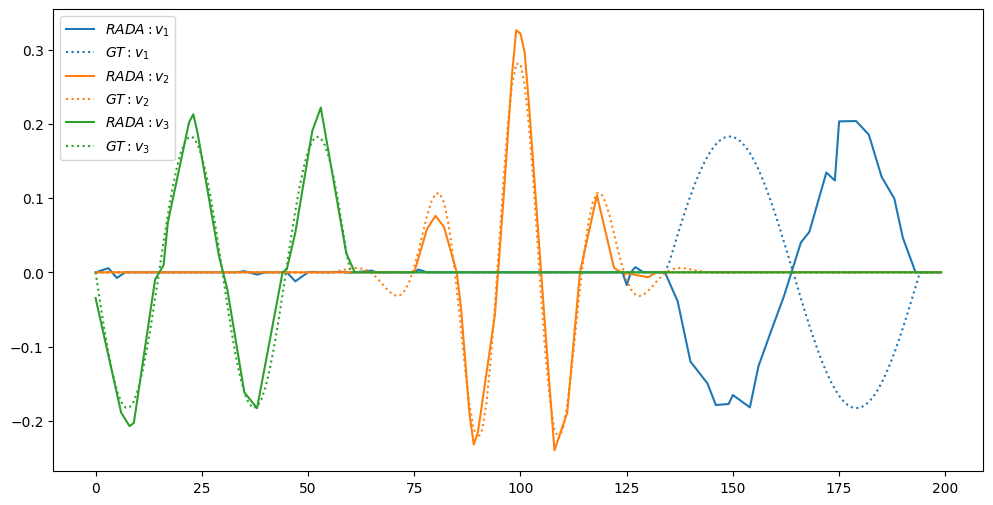

In [7]:
U_tilde = result.point.x
Y_tilde = result.point.y

U_t = U_tilde.cpu().numpy()
Y_t = Y_tilde.cpu().numpy()

X = torch.tensor(X, dtype=torch.float64, device='cuda')
U_svd, s_svd, V_svd = torch.linalg.svd(X, full_matrices=False)

V_svd = V_svd.T
V_svd = V_svd[:, :K]

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
colors = ['C0', 'C1', 'C2']

for i in range(K):
    v_rada = U_t[:, i]
    # if v_svd.sum() <= 0:
    #     v_svd = -v_svd
    ax.plot(v_rada, label=f"$RADA: v_{i+1}$", color=colors[i])

    v_gt = V[:, i]
    # if v_gt.sum() <= 0:
    #     v_gt = -v_gt
    ax.plot(v_gt, label=f"$GT: v_{i+1}$", color=colors[i], linestyle='dotted')

ax.legend()

/tmp/ipykernel_2141209/2742214469.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X, dtype=torch.float64, device='cuda')


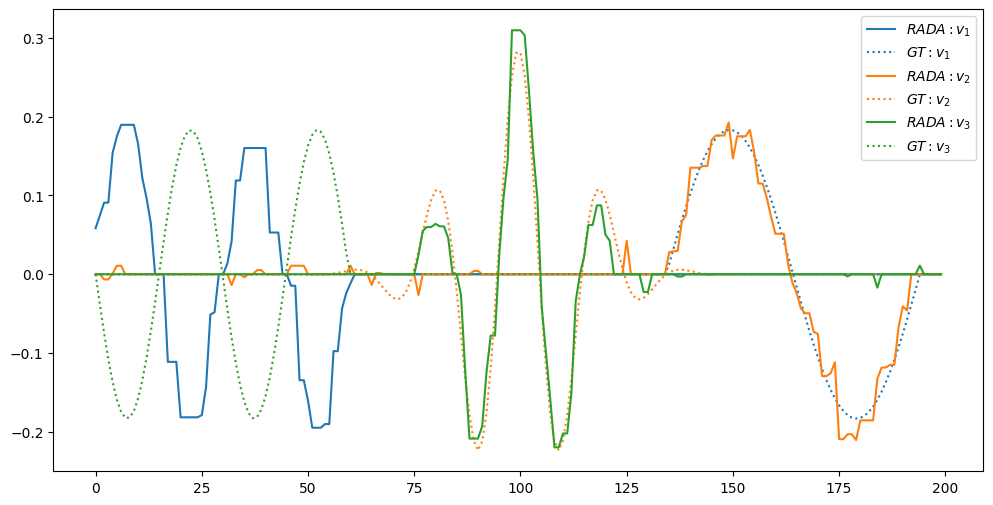

In [190]:
U_tilde = result.point.x
Y_tilde = result.point.y

U_t = U_tilde.cpu().numpy()
Y_t = Y_tilde.cpu().numpy()

X = torch.tensor(X, dtype=torch.float64, device='cuda')
U_svd, s_svd, V_svd = torch.linalg.svd(X, full_matrices=False)

V_svd = V_svd.T
V_svd = V_svd[:, :K]

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
colors = ['C0', 'C1', 'C2']

for i in range(K):
    v_rada = U_t[:, i]
    # if v_svd.sum() <= 0:
    #     v_svd = -v_svd
    ax.plot(v_rada, label=f"$RADA: v_{i+1}$", color=colors[i])

    v_gt = V[:, i]
    # if v_gt.sum() <= 0:
    #     v_gt = -v_gt
    ax.plot(v_gt, label=f"$GT: v_{i+1}$", color=colors[i], linestyle='dotted')

ax.legend()